# Autoencoder → Representation → Clustering → Evaluation

**Objective:**
1. Build a CNN autoencoder (encoder → 128D latent → decoder)
2. Train it to reconstruct WikiArt images
3. Extract latent embeddings
4. Reduce dimensionality (PCA → 2D for visualization)
5. Perform clustering (KMeans)
6. Compare clusters with `style` and `artist` labels (ARI, NMI, purity)

## 0. Imports and Setup

In [2]:
import os
from pathlib import Path
import time
from contextlib import nullcontext
import json
from datasets import Dataset as HFDataset
from PIL import Image
import io

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset as TorchDataset
import torchvision.transforms as T

from datasets import load_dataset, Image as HFImage
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from tqdm import tqdm

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

Device: cuda


## 1. Load Local Parquet Dataset

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set data directory to your Drive location
os.environ["DATA_DIR"] = "/content/drive/MyDrive/UN//dataWikiArt"

Mounted at /content/drive


In [4]:
DATA_DIR = Path(os.getenv("DATA_DIR", "../../dataset1/data")).resolve()
print("Data dir:", DATA_DIR)

files = sorted(str(p) for p in DATA_DIR.rglob("*.parquet"))
print("Found parquet files:", len(files))
if not files:
    raise SystemExit("No .parquet files found under ./dataset1/data. Upload/mount your data there.")

# Persist dataset splits to disk for faster reloading
ARTIFACTS_DIR = Path("artifacts"); ARTIFACTS_DIR.mkdir(exist_ok=True)
TRAIN_DS_PATH = ARTIFACTS_DIR / "train_ds"
VAL_DS_PATH = ARTIFACTS_DIR / "val_ds"
TEST_DS_PATH = ARTIFACTS_DIR / "test_ds"

if TRAIN_DS_PATH.exists() and VAL_DS_PATH.exists() and TEST_DS_PATH.exists():
    print("Loading existing dataset splits from disk...")
    train_ds = HFDataset.load_from_disk(TRAIN_DS_PATH)
    val_ds = HFDataset.load_from_disk(VAL_DS_PATH)
    test_ds = HFDataset.load_from_disk(TEST_DS_PATH)
else:
    print("Loading dataset from local parquet and creating new splits...")
    ds_full = load_dataset("parquet", data_files=files, split="train").cast_column("image", HFImage())
    print("Total records:", len(ds_full))
    print("Columns:", ds_full.column_names)

    # Persist split indices so future runs reuse the same split
    SPLITS_PATH = ARTIFACTS_DIR / "dataset_splits.json"

    if SPLITS_PATH.exists():
        print("Loading existing split indices...")
        split_indices = json.loads(SPLITS_PATH.read_text())
    else:
        print("Creating new 80/10/10 split (stratified by 'style' if available)...")
        ds_full = ds_full.add_column("idx", list(range(len(ds_full))))
        try:
            s1 = ds_full.train_test_split(test_size=0.20, stratify_by_column="style", seed=42)
            s2 = s1["test"].train_test_split(test_size=0.50, stratify_by_column="style", seed=42)
        except Exception as e:
            print("Stratified split failed, falling back to random split:", e)
            s1 = ds_full.train_test_split(test_size=0.20, seed=42)
            s2 = s1["test"].train_test_split(test_size=0.50, seed=42)

        train_ds_temp, val_ds_temp, test_ds_temp = s1["train"], s2["train"], s2["test"]
        split_indices = {
            "train": list(train_ds_temp["idx"]),
            "val": list(val_ds_temp["idx"]),
            "test": list(test_ds_temp["idx"]),
        }
        SPLITS_PATH.write_text(json.dumps(split_indices))
        print("Saved split indices to", SPLITS_PATH)

    # Rebuild splits from indices
    train_ds = ds_full.select(split_indices["train"])
    val_ds   = ds_full.select(split_indices["val"])
    test_ds  = ds_full.select(split_indices["test"])

    # Save splits to disk
    train_ds.save_to_disk(TRAIN_DS_PATH)
    val_ds.save_to_disk(VAL_DS_PATH)
    test_ds.save_to_disk(TEST_DS_PATH)
    print(f"Saved dataset splits to {ARTIFACTS_DIR}")

print(f"Train={len(train_ds)} Val={len(val_ds)} Test={len(test_ds)}")

Data dir: /content/drive/MyDrive/UN/dataWikiArt
Found parquet files: 7
Loading dataset from local parquet and creating new splits...


Generating train split: 0 examples [00:00, ? examples/s]

Total records: 103250
Columns: ['title', 'artist', 'date', 'genre', 'style', 'description', 'filename', 'image', 'embeddings_pca512', 'resnet50_non_robust_feats', 'resnet50_robust_feats']
Creating new 80/10/10 split (stratified by 'style' if available)...
Stratified split failed, falling back to random split: Stratifying by column is only supported for ClassLabel column, and column style is Value.
Saved split indices to artifacts/dataset_splits.json


Saving the dataset (0/6 shards):   0%|          | 0/82600 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/10325 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/10325 [00:00<?, ? examples/s]

Saved dataset splits to artifacts
Train=82600 Val=10325 Test=10325


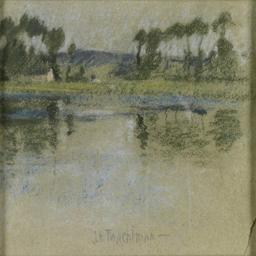

In [5]:
train_ds['image'][0]

## 2. Transforms and Dataset Wrapper

In [6]:
# Speed knobs
IMG_SIZE = int(os.getenv("IMG_SIZE", "128"))
LATENT_DIM = int(os.getenv("LATENT_DIM", "128"))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "64" if torch.cuda.is_available() else "32"))
NUM_WORKERS = int(os.getenv("NUM_WORKERS", "2"))
# NUM_WORKERS = 0


# Subset for quick iterations (0 = use all)
MAX_TRAIN = int(os.getenv("MAX_TRAIN", "0"))
MAX_VAL   = int(os.getenv("MAX_VAL", "0"))
MAX_TEST  = int(os.getenv("MAX_TEST", "0"))

def maybe_subset(ds, limit):
    return ds.select(range(min(limit, len(ds)))) if (limit and limit > 0) else ds

train_ds_sub = maybe_subset(train_ds, MAX_TRAIN)
val_ds_sub   = maybe_subset(val_ds,   MAX_VAL)
test_ds_sub  = maybe_subset(test_ds,  MAX_TEST)

print(f"Using train={len(train_ds_sub)} val={len(val_ds_sub)} test={len(test_ds_sub)}")

# Transforms
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(), # Convert from PIL Image [0,255] to float tensor [0.0,1.0]
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Scale to [-1, 1]
])

class WikiArtDataset(TorchDataset):
    """Wrap HF dataset, apply transforms, return image + labels."""
    def __init__(self, hf_dataset, transform=None):
        self.ds = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        if isinstance(idx, torch.Tensor):
            idx = idx.item()
        row = self.ds[int(idx)]

        img = row["image"]  # powinien być PIL.Image po cast_column
        # Awaryjna obsługa jeśli jednak dict/list
        if isinstance(img, list):
            img = img[0]
        if isinstance(img, dict):
            if "bytes" in img:
                img = Image.open(io.BytesIO(img["bytes"]))
            elif "path" in img:
                img = Image.open(img["path"])
        if not isinstance(img, Image.Image):
            raise TypeError(f"Unexpected image type: {type(img)} at idx={idx}")

        if img.mode != "RGB":
            img = img.convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, row.get("style", "unknown"), row.get("artist", "unknown")


pin_mem = torch.cuda.is_available()
train_loader = DataLoader(WikiArtDataset(train_ds_sub, transform=transform),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=pin_mem)
val_loader   = DataLoader(WikiArtDataset(val_ds_sub, transform=transform),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin_mem)
test_loader  = DataLoader(WikiArtDataset(test_ds_sub, transform=transform),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin_mem)

print(f"Batches -> train:{len(train_loader)} val:{len(val_loader)} test:{len(test_loader)}")

Using train=82600 val=10325 test=10325
Batches -> train:1291 val:162 test:162


In [7]:
sample_row = train_ds_sub[0]
print("DEBUG image type:", type(sample_row["image"]), "keys?" , (sample_row["image"].keys() if isinstance(sample_row["image"], dict) else None))

DEBUG image type: <class 'PIL.JpegImagePlugin.JpegImageFile'> keys? None


## 3. Autoencoder Definition (CNN)

In [8]:
class Autoencoder(nn.Module):
    """CNN Autoencoder: 3xIMG_SIZExIMG_SIZE -> latent -> 3xIMG_SIZExIMG_SIZE."""
    def __init__(self, latent_dim=128, img_size=128):
        super().__init__()
        s = img_size // 16  # after 4 downsamples (stride=2)
        self._s = s

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),   # -> 32 x (img/2)
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),  # -> 64 x (img/4)
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(), # -> 128 x (img/8)
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),# -> 256 x (img/16)
            nn.Flatten(),
            nn.Linear(256 * s * s, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256 * s * s),
            nn.Unflatten(1, (256, s, s)),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

model = Autoencoder(latent_dim=LATENT_DIM, img_size=IMG_SIZE).to(device)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=16384, out_features=128, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=16384, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(256, 8, 8))
    (2): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): ConvTranspose2d(32, 3, kernel

## 3.5 Custom MSE (Based on Sobel edges)


In [9]:
import torch.nn.functional as F

def sobel_edges(imgs):
    """
    imgs: tensor [B, 3, H, W] w zakresie [-1,1] lub [0,1]
    Returns: gradient magnitude [B, 1, H, W]
    """

    # Sobel kernels (3x3)
    sobel_x = torch.tensor([
        [-1., 0., 1.],
        [-2., 0., 2.],
        [-1., 0., 1.]
    ], device=imgs.device).expand(3, 1, 3, 3)

    sobel_y = torch.tensor([
        [-1., -2., -1.],
        [ 0.,  0.,  0.],
        [ 1.,  2.,  1.]
    ], device=imgs.device).expand(3, 1, 3, 3)

    # apply to each channel independently
    gx = F.conv2d(imgs, sobel_x, padding=1, groups=3)
    gy = F.conv2d(imgs, sobel_y, padding=1, groups=3)

    # gradient magnitude
    mag = torch.sqrt(gx ** 2 + gy ** 2 + 1e-6)

    # convert to single channel (mean over RGB channels)
    mag = mag.mean(dim=1, keepdim=True)

    return mag

def sobel_mse_loss(recon, target):
    recon_edges = sobel_edges(recon)
    target_edges = sobel_edges(target)
    return F.mse_loss(recon_edges, target_edges)

## 4. Autoencoder Training

In [10]:
EPOCHS = int(os.getenv("EPOCHS", "6"))
LR = float(os.getenv("LR", "1e-3"))

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
amp_ctx = torch.autocast(device_type="cuda", dtype=torch.float16) if use_amp else nullcontext()

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    train_loss = 0.0

    for imgs, _, _ in tqdm(train_loader, desc=f"Train {epoch}/{EPOCHS}", ncols=100):
        imgs = imgs.to(device, non_blocking=True)

        with amp_ctx:
            recon, _ = model(imgs)
            loss = criterion(recon, imgs)

        optimizer.zero_grad(set_to_none=True)
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        train_loss += loss.item() * imgs.size(0)

    train_loss /= max(1, len(train_loader.dataset))

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, _, _ in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            recon, _ = model(imgs)
            loss = criterion(recon, imgs)
            val_loss += loss.item() * imgs.size(0)
    val_loss /= max(1, len(val_loader.dataset))

    dt = time.time() - t0
    print(f"Epoch {epoch}/{EPOCHS} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | time={dt/60:.2f} min")

print("Training finished")

Train 1/6: 100%|████████████████████████████████████████████████| 1291/1291 [05:20<00:00,  4.02it/s]


Epoch 1/6 | train_loss=0.074236 | val_loss=0.044887 | time=6.00 min


Train 2/6: 100%|████████████████████████████████████████████████| 1291/1291 [05:14<00:00,  4.10it/s]


Epoch 2/6 | train_loss=0.042795 | val_loss=0.041292 | time=5.90 min


Train 3/6: 100%|████████████████████████████████████████████████| 1291/1291 [05:15<00:00,  4.09it/s]


...

Epoch 4/6 | train_loss=0.040212 | val_loss=0.040014 | time=5.89 min


Train 5/6: 100%|████████████████████████████████████████████████| 1291/1291 [05:13<00:00,  4.11it/s]


Epoch 5/6 | train_loss=0.039780 | val_loss=0.039975 | time=5.89 min


Train 6/6: 100%|████████████████████████████████████████████████| 1291/1291 [05:14<00:00,  4.11it/s]


Epoch 6/6 | train_loss=0.039462 | val_loss=0.040016 | time=5.89 min
Training finished


In [11]:
## 5. Save Model and Reconstruction Check

## 6. Extract Embeddings

In [12]:
# Extract latent embeddings over the training set
model.eval()
embeddings, all_styles, all_artists = [], [], []
with torch.no_grad():
    for imgs, styles, artists in tqdm(train_loader, desc="Embedding", ncols=100):
        imgs = imgs.to(device, non_blocking=True)
        _, z = model(imgs)
        embeddings.append(z.cpu().numpy())
        all_styles.extend(styles)
        all_artists.extend(artists)

embeddings = np.concatenate(embeddings, axis=0)
print("Embeddings shape:", embeddings.shape)

Embedding: 100%|████████████████████████████████████████████████| 1291/1291 [05:15<00:00,  4.09it/s]

Embeddings shape: (82600, 128)


## 7. PCA Dimensionality Reduction

In [13]:
# PCA 50D for clustering + 2D for visualization
pca50 = PCA(n_components=50, random_state=42)
emb_50d = pca50.fit_transform(embeddings)

pca2 = PCA(n_components=2, random_state=42)
emb_2d = pca2.fit_transform(embeddings)
print(f"PCA -> 50D: {emb_50d.shape} | 2D: {emb_2d.shape}")

PCA -> 50D: (82600, 50) | 2D: (82600, 2)


## 8. KMeans Clustering

In [14]:
# Determine number of clusters from unique styles (bounded 5-30)
unique_styles = set(all_styles)
k = max(5, min(30, len(unique_styles)))
print(f"Unique styles: {len(unique_styles)} -> K={k}")

kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(emb_50d)

print(f"Cluster counts: {Counter(cluster_labels)}")

Unique styles: 136 -> K=30
Cluster counts: Counter({np.int32(19): 5701, np.int32(18): 5430, np.int32(9): 5290, np.int32(22): 4610, np.int32(11): 3638, np.int32(26): 3604, np.int32(13): 3484, np.int32(10): 3302, np.int32(5): 3113, np.int32(8): 3104, np.int32(24): 2906, np.int32(16): 2851, np.int32(25): 2766, np.int32(17): 2573, np.int32(27): 2515, np.int32(2): 2403, np.int32(14): 2394, np.int32(3): 2348, np.int32(20): 2299, np.int32(23): 2270, np.int32(28): 2188, np.int32(12): 2171, np.int32(6): 1926, np.int32(15): 1824, np.int32(0): 1788, np.int32(7): 1694, np.int32(1): 1478, np.int32(4): 1254, np.int32(29): 1168, np.int32(21): 508})


## 9. Evaluation Metrics (ARI, NMI, Purity)

In [15]:
# Define purity metric
def purity_score(pred_clusters, true_labels):
    """Purity = sum over clusters of the dominant class count / total."""
    from collections import defaultdict
    groups = defaultdict(list)
    for c, t in zip(pred_clusters, true_labels):
        groups[int(c)].append(t)
    total = len(true_labels)
    correct = sum(Counter(v).most_common(1)[0][1] for v in groups.values())
    return correct / max(total, 1)

# Convert to arrays
style_arr = np.array(all_styles)
artist_arr = np.array(all_artists)

# Compute metrics vs style
ari_style = adjusted_rand_score(style_arr, cluster_labels)
nmi_style = normalized_mutual_info_score(style_arr, cluster_labels)
pur_style = purity_score(cluster_labels, all_styles)

# Compute metrics vs artist
ari_artist = adjusted_rand_score(artist_arr, cluster_labels)
nmi_artist = normalized_mutual_info_score(artist_arr, cluster_labels)
pur_artist = purity_score(cluster_labels, all_artists)

print("\n=== STYLE ===")
print(f"ARI: {ari_style:.4f}")
print(f"NMI: {nmi_style:.4f}")
print(f"Purity: {pur_style:.4f}")

print("\n=== ARTIST ===")
print(f"ARI: {ari_artist:.4f}")
print(f"NMI: {nmi_artist:.4f}")
print(f"Purity: {pur_artist:.4f}")


=== STYLE ===
ARI: 0.0133
NMI: 0.0739
Purity: 0.1451

=== ARTIST ===
ARI: 0.0044
NMI: 0.1637
Purity: 0.0248


## 10. Visualization and Save Artifacts

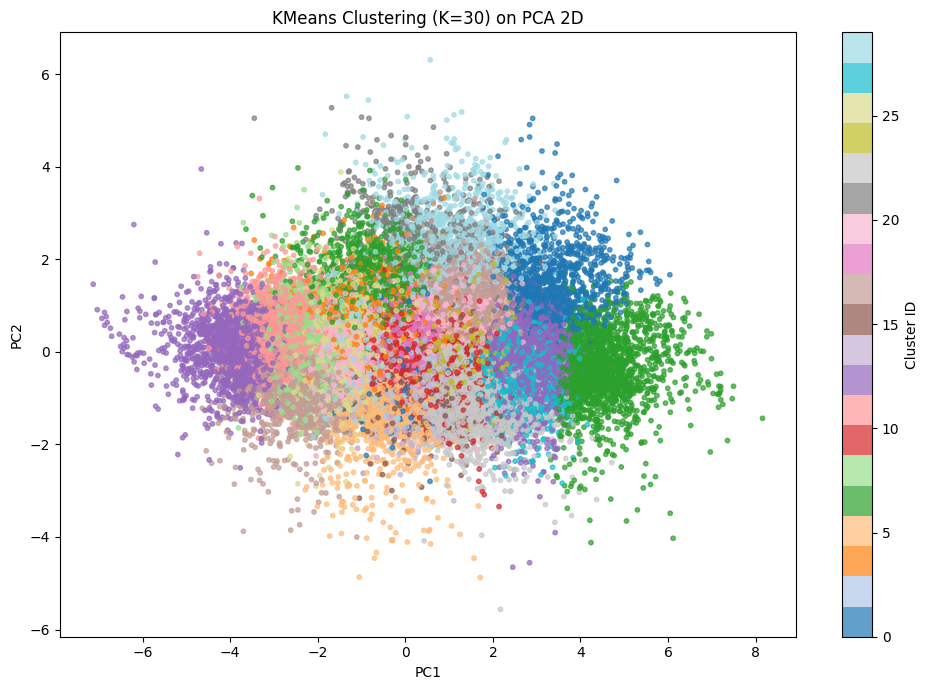

Plot saved: /content/artifacts/clusters_pca2d.png
Artifacts saved in: /content/artifacts


In [16]:
# Scatter plot by cluster
plt.figure(figsize=(10, 7))
scatter = plt.scatter(emb_2d[:,0], emb_2d[:,1], c=cluster_labels, cmap='tab20', s=10, alpha=0.7)
plt.colorbar(scatter, label="Cluster ID")
plt.title(f"KMeans Clustering (K={k}) on PCA 2D")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plot_path = ARTIFACTS_DIR / "clusters_pca2d.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print("Plot saved:", plot_path.resolve())

# Save arrays and CSV
np.savez(ARTIFACTS_DIR / "embeddings_autoencoder.npz",
         embeddings_128d=embeddings,
         embeddings_50d=emb_50d,
         embeddings_2d=emb_2d,
         cluster_labels=cluster_labels)

import csv
with open(ARTIFACTS_DIR / "cluster_assignments.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["index", "cluster", "style", "artist"])
    for i, (c, s, a) in enumerate(zip(cluster_labels, all_styles, all_artists)):
        w.writerow([i, int(c), s, a])

with open(ARTIFACTS_DIR / "clustering_metrics.txt", "w", encoding="utf-8") as f:
    f.write("=== STYLE ===\n")
    f.write(f"ARI: {ari_style:.6f}\n")
    f.write(f"NMI: {nmi_style:.6f}\n")
    f.write(f"Purity: {pur_style:.6f}\n\n")
    f.write("=== ARTIST ===\n")
    f.write(f"ARI: {ari_artist:.6f}\n")
    f.write(f"NMI: {nmi_artist:.6f}\n")
    f.write(f"Purity: {pur_artist:.6f}\n")

print("Artifacts saved in:", ARTIFACTS_DIR.resolve())

## 11. Decoding from letent

In [17]:
EPOCHS_DEC = int(os.getenv("EPOCHS_DEC", "8"))
LR_DEC = float(os.getenv("LR_DEC", "1e-3"))
PRINT_EVERY = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Freeze encoder (do not train it)
for p in model.encoder.parameters():
    p.requires_grad = False

# Ensure decoder is trainable
for p in model.decoder.parameters():
    p.requires_grad = True

optimizer_dec = optim.Adam(model.decoder.parameters(), lr=LR_DEC)
criterion = nn.MSELoss()

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler(enabled=use_amp)
amp_ctx = torch.autocast(device_type="cuda", dtype=torch.float16) if use_amp else nullcontext()

for epoch in range(1, EPOCHS_DEC + 1):
    t0 = time.time()
    model.train()
    running_loss = 0.0
    n_samples = 0

    for imgs, _, _ in tqdm(train_loader, desc=f"Decoder Train {epoch}/{EPOCHS_DEC}", ncols=100):
        imgs = imgs.to(device, non_blocking=True)

        # get latent without grads
        with torch.no_grad():
            z = model.encoder(imgs)

        with amp_ctx:
            recon = model.decoder(z)
            loss = criterion(recon, imgs)

        optimizer_dec.zero_grad(set_to_none=True)
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer_dec)
            scaler.update()
        else:
            loss.backward()
            optimizer_dec.step()

        bs = imgs.size(0)
        running_loss += loss.item() * bs
        n_samples += bs

    epoch_loss = running_loss / max(1, n_samples)
    dt = time.time() - t0
    if epoch % PRINT_EVERY == 0:
        print(f"Epoch {epoch}/{EPOCHS_DEC} | decoder_train_loss={epoch_loss:.6f} | time={dt/60:.2f} min")

print("Decoder training finished.")

# Save decoder weights
DEC_PATH = ARTIFACTS_DIR / "decoder_only.pth"
torch.save(model.decoder.state_dict(), DEC_PATH)
print("Saved decoder weights to:", DEC_PATH.resolve())


Device: cuda


Decoder Train 1/8: 100%|████████████████████████████████████████| 1291/1291 [05:13<00:00,  4.12it/s]


Epoch 1/8 | decoder_train_loss=0.038644 | time=5.23 min


Decoder Train 2/8: 100%|████████████████████████████████████████| 1291/1291 [05:14<00:00,  4.11it/s]


Epoch 2/8 | decoder_train_loss=0.038408 | time=5.24 min


...

Epoch 6/8 | decoder_train_loss=0.037688 | time=5.23 min


Decoder Train 7/8: 100%|████████████████████████████████████████| 1291/1291 [05:14<00:00,  4.11it/s]


Epoch 7/8 | decoder_train_loss=0.037534 | time=5.24 min


Decoder Train 8/8: 100%|████████████████████████████████████████| 1291/1291 [05:12<00:00,  4.13it/s]

Epoch 8/8 | decoder_train_loss=0.037379 | time=5.21 min
Decoder training finished.
Saved decoder weights to: /content/artifacts/decoder_only.pth


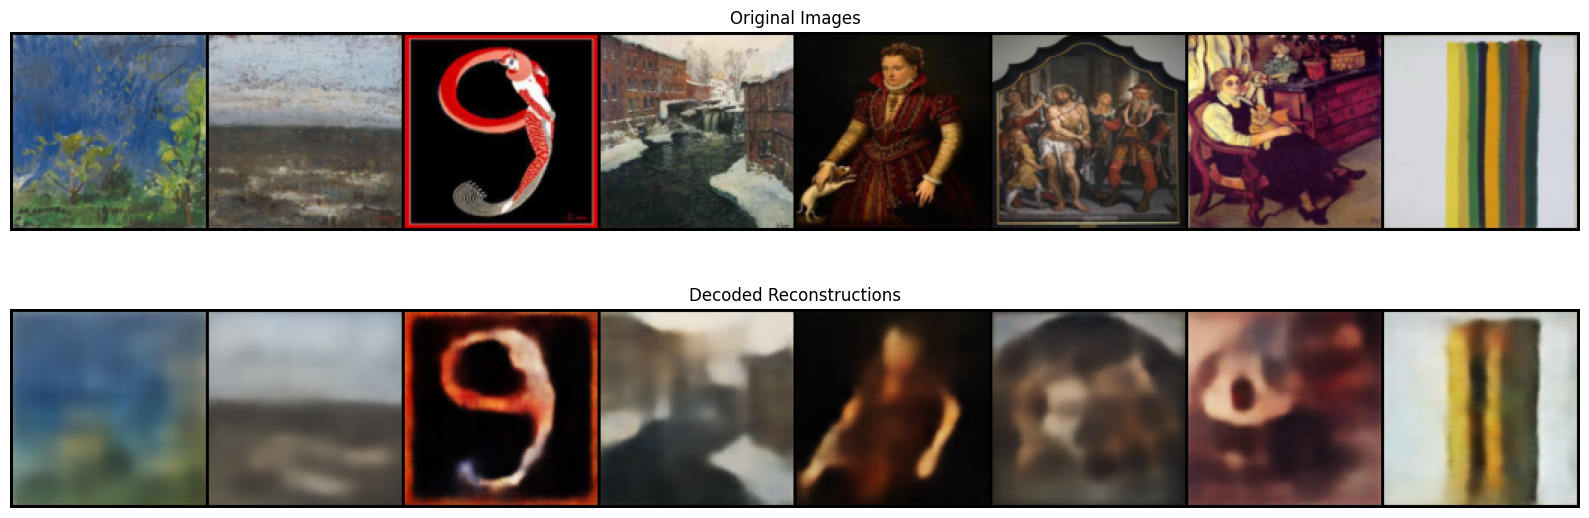

Saved reconstruction plot to: /content/artifacts/decoder_recons.png


In [18]:
# helper: denormalize from [-1,1] -> [0,1]
def denormalize(t):
    return (t * 0.5) + 0.5

model.eval()
with torch.no_grad():
    imgs_batch, _, _ = next(iter(val_loader))
    imgs_batch = imgs_batch.to(device, non_blocking=True)

    # encoder -> latent -> decoder
    z = model.encoder(imgs_batch)
    recon_batch = model.decoder(z)

# convert to CPU and denormalize
orig = denormalize(imgs_batch.cpu()).clamp(0, 1)
recon = denormalize(recon_batch.cpu()).clamp(0, 1)

import torchvision.utils as vutils

N = min(8, orig.size(0))

orig_grid = vutils.make_grid(orig[:N], nrow=N, normalize=False)
recon_grid = vutils.make_grid(recon[:N], nrow=N, normalize=False)

plt.figure(figsize=(16, 6))

plt.subplot(2, 1, 1)
plt.imshow(np.transpose(orig_grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Original Images")

plt.subplot(2, 1, 2)
plt.imshow(np.transpose(recon_grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Decoded Reconstructions")

plt.tight_layout()

plot_path = ARTIFACTS_DIR / "decoder_recons.png"
plt.savefig(plot_path, dpi=150)
plt.show()

print("Saved reconstruction plot to:", plot_path.resolve())
